# Seed analysis for realistic small town

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import time
import infection_model as model

DAYS = 60
N_AGENTS = 5000

params = model.Params(
    T=DAYS * 24,
    N=N_AGENTS,
    alpha=3,
    initial_infected_normal=3,
    initial_infected_multispreader=0,
    exposed=0,
    ratios=model.AgentTypeRatio(retired=0.2, adult=0.6, child=0.2),
    schools=4,
    primary_care=20,
    hospitals=1,
    other_working_places=100,
    public_places=50
)

# --- Plot ---
def plot_results(df, N):
    colors = {
        "S": "tab:blue", "E": "gold", "I_total": "orange",
        "H": "tab:red", "R": "tab:green", "D": "black"
    }
    plt.figure(figsize=(8, 4))
    
    if "I_total" not in df.columns:
        df["I_total"] = df["I0"] + df["I1"] + df["I2"]

    plt.plot(df["days"], df["S"], label="Susceptible", color=colors["S"], linestyle="--")
    plt.plot(df["days"], df["E"], label="Exposed", color=colors["E"])
    plt.plot(df["days"], df["I_total"], label="Infectious (Total)", color=colors["I_total"], linewidth=2.5)
    plt.plot(df["days"], df["H"], label="Hospitalized", color=colors["H"])
    plt.plot(df["days"], df["R"], label="Recovered", color=colors["R"])
    plt.plot(df["days"], df["D"], label="Dead", color=colors["D"])

    plt.xlabel("Days")
    plt.ylabel("Population Count")
    plt.title(f"SEIRHD Model (Init I0_N={params.initial_infected_normal} I0_M={params.initial_infected_multispreader})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Reproducibility

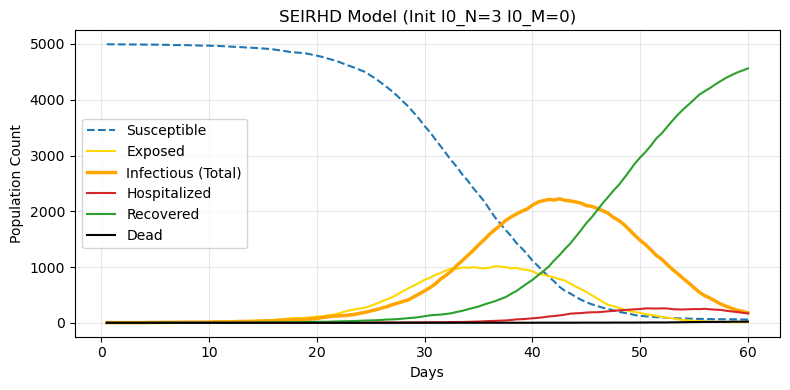

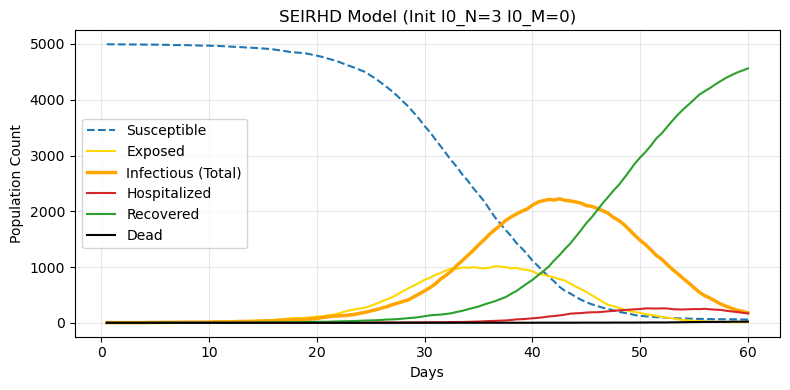

In [2]:
for i in range(2):
    sim = model.Simulation(params=params, seed=12)
    sim.init()
    sim.run(dt=12.0) 
    df = pd.DataFrame(sim.get_stats_df())
    df["days"] = df["time"] / 24
    plot_results(df, params.N)

## A few simulations with same parameters

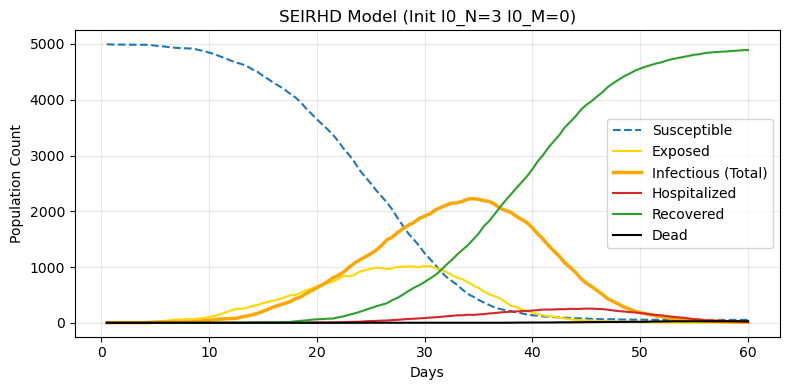

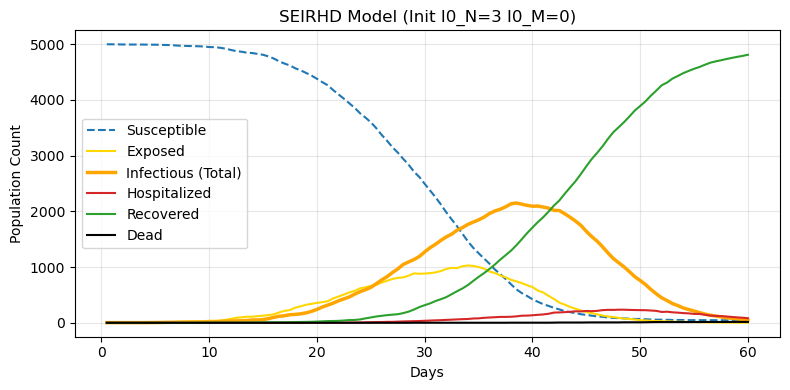

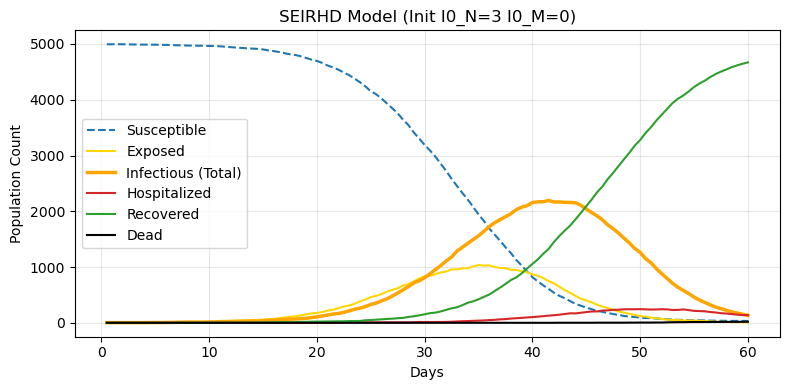

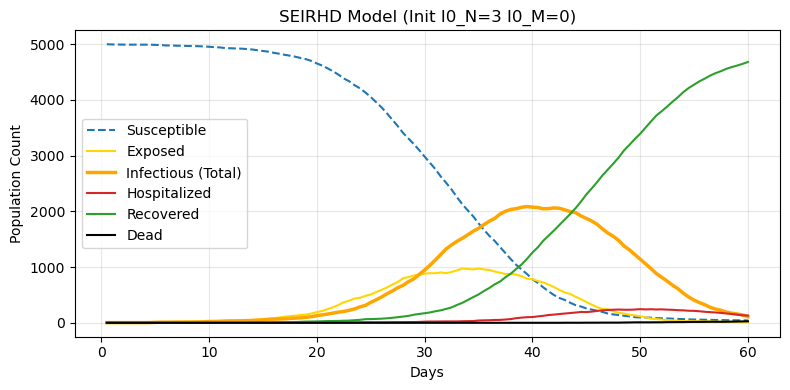

In [3]:
for i in range(4):
    sim = model.Simulation(params=params, seed=i)
    sim.init()
    sim.run(dt=12.0) 
    df = pd.DataFrame(sim.get_stats_df())
    df["days"] = df["time"] / 24
    plot_results(df, params.N)

## Impact of number of initially infected (can be not very informative -- one simulation)

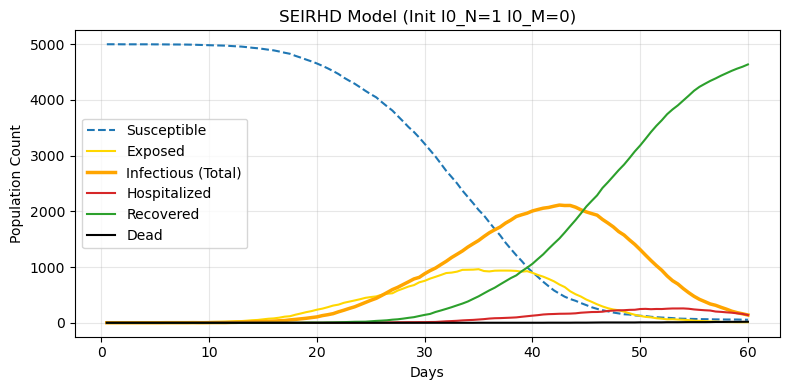

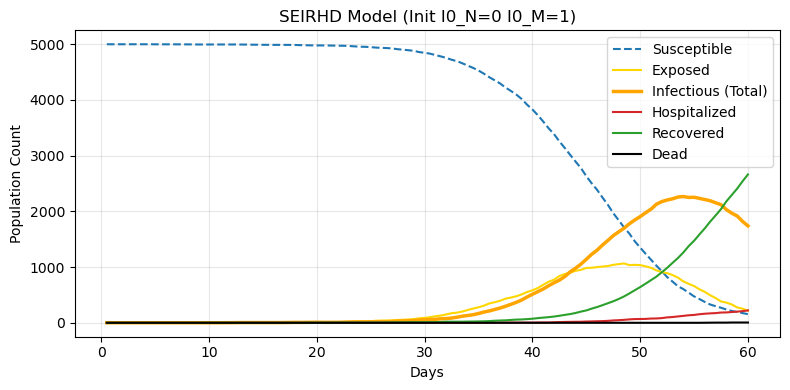

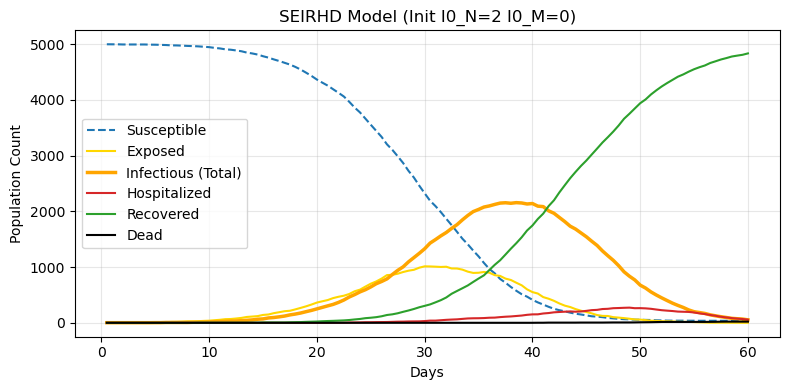

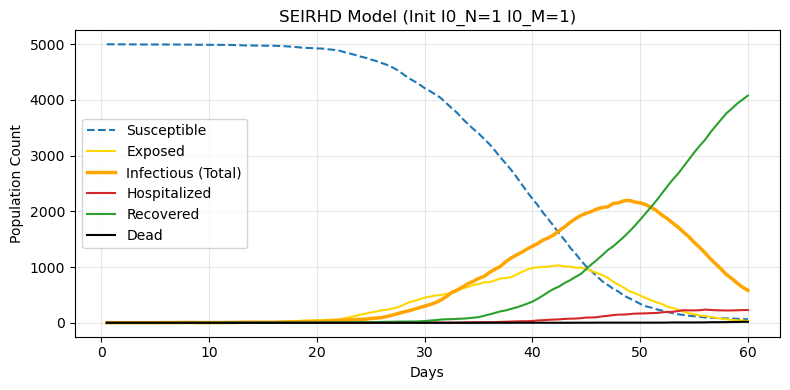

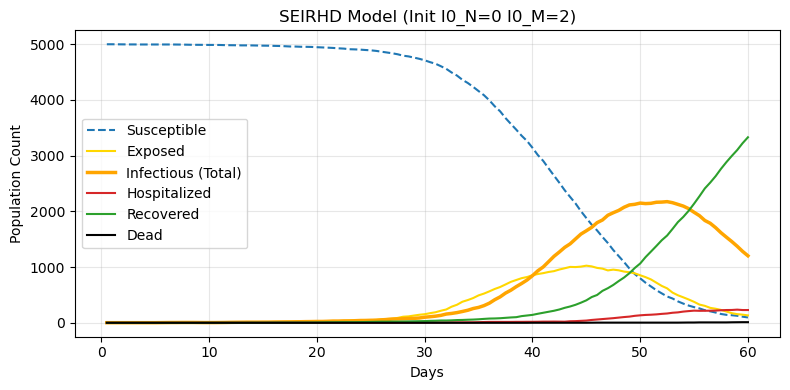

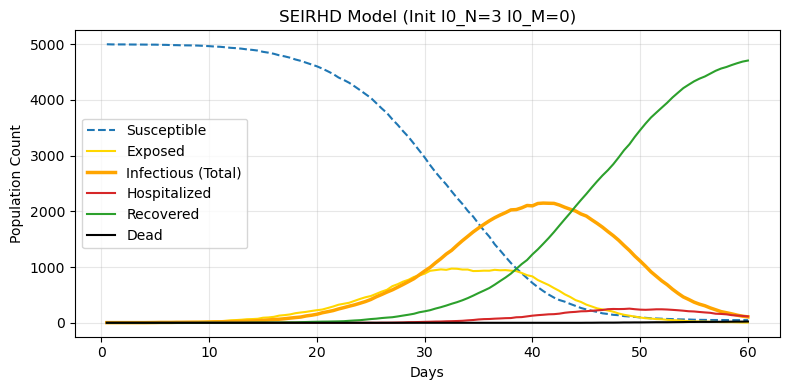

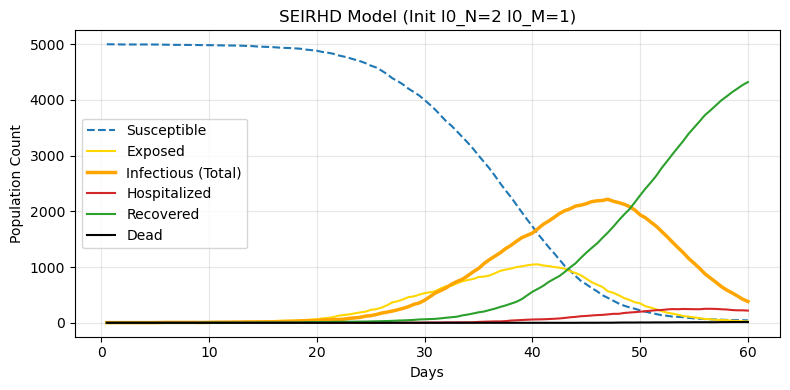

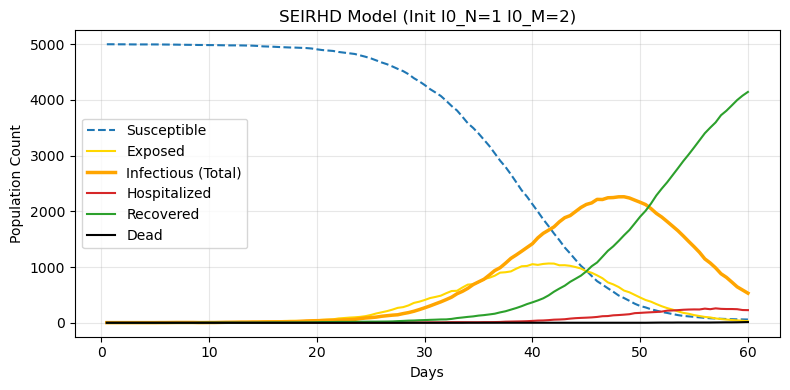

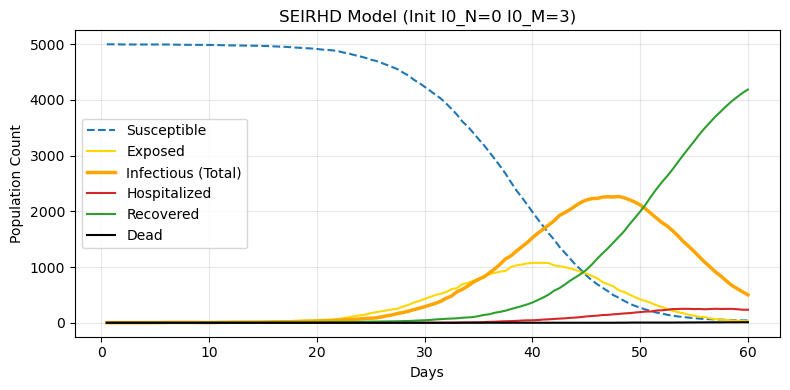

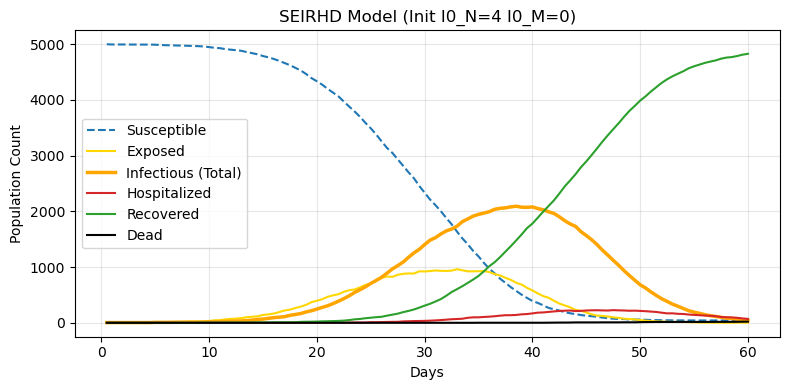

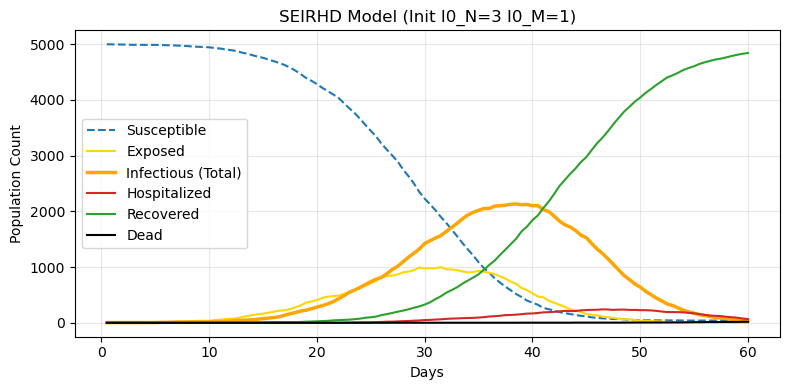

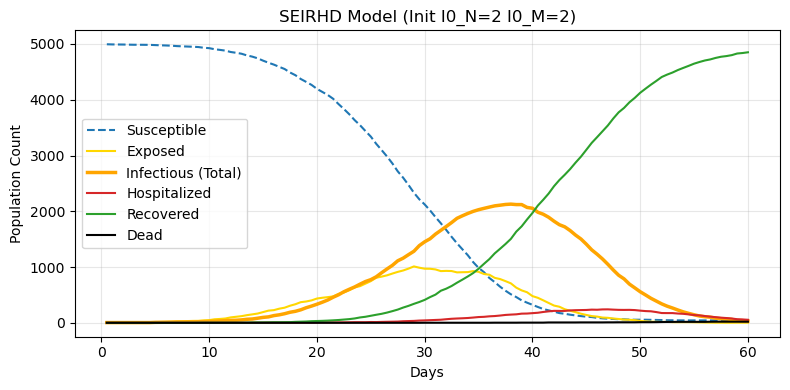

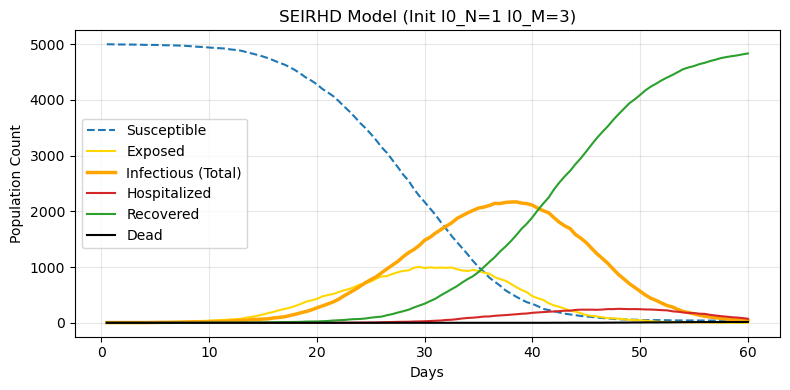

In [4]:
DAYS=60
for i in range(1,5):
    for j in range(min(i,3)+1):
        params = model.Params(
            T=DAYS * 24,
            N=N_AGENTS,
            alpha=3,
            initial_infected_normal=i-j,
            initial_infected_multispreader=j,
            exposed=0,                        
            ratios=model.AgentTypeRatio(retired=0.2, adult=0.6, child=0.2),
            schools=4,
            primary_care=20,
            hospitals=1,
            other_working_places=100,
            public_places=50
        )
        sim = model.Simulation(params=params, seed=22)
        sim.init()
        sim.run(dt=12.0) 
        df = pd.DataFrame(sim.get_stats_df())
        df["days"] = df["time"] / 24
        plot_results(df, params.N)

## Does model die out?

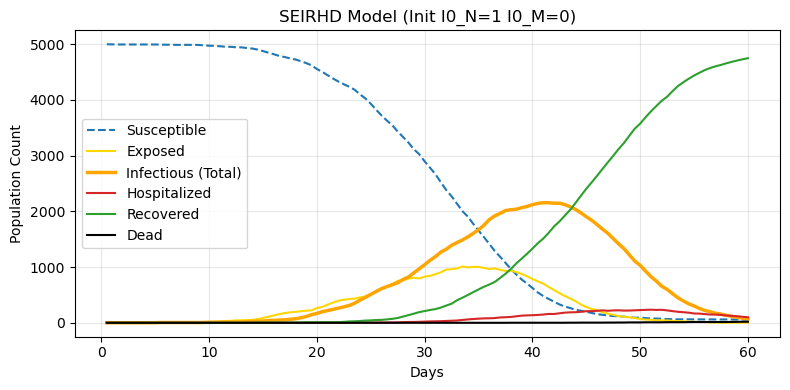

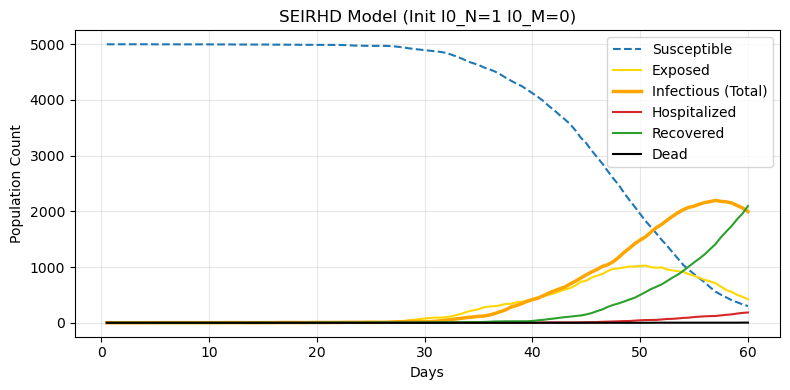

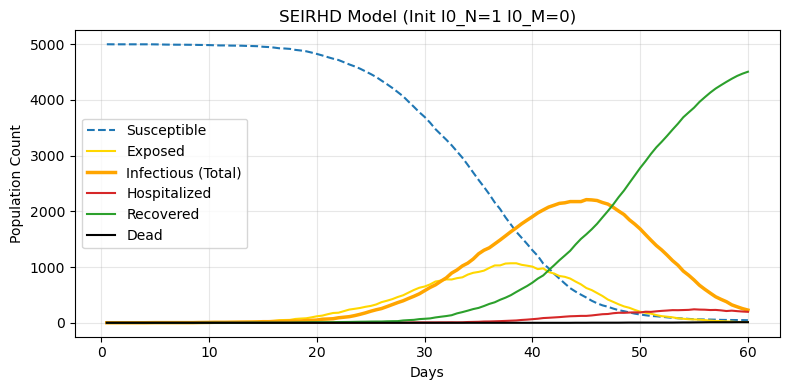

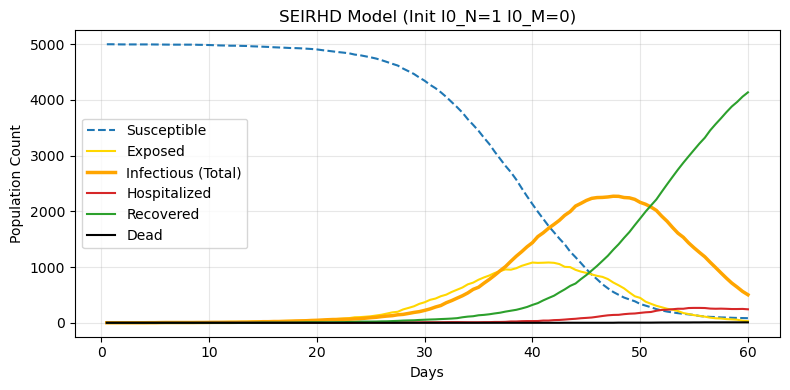

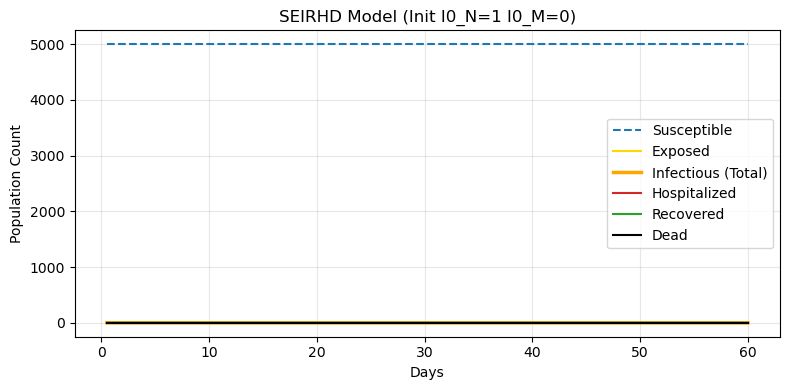

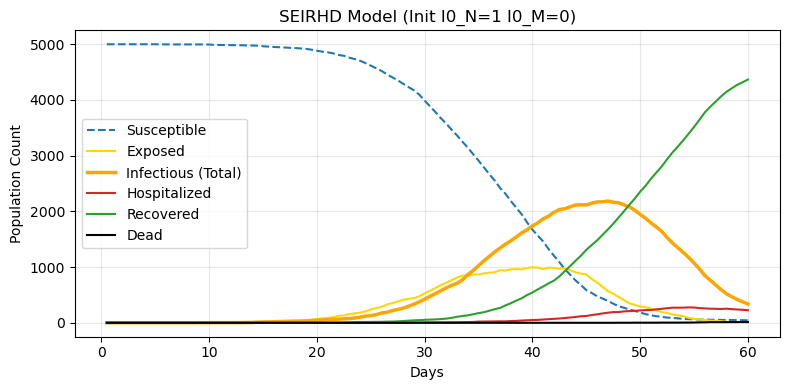

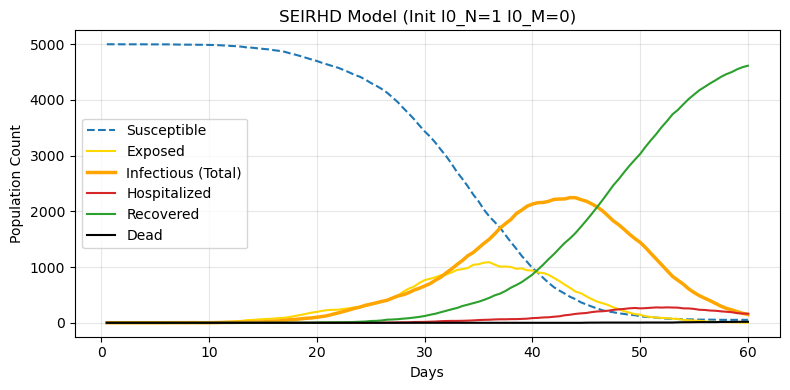

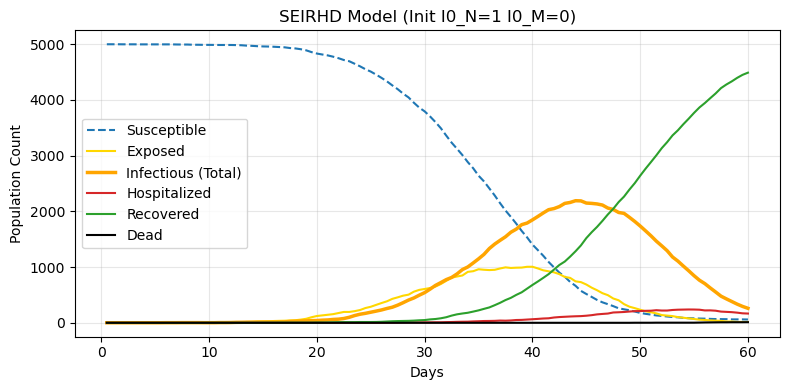

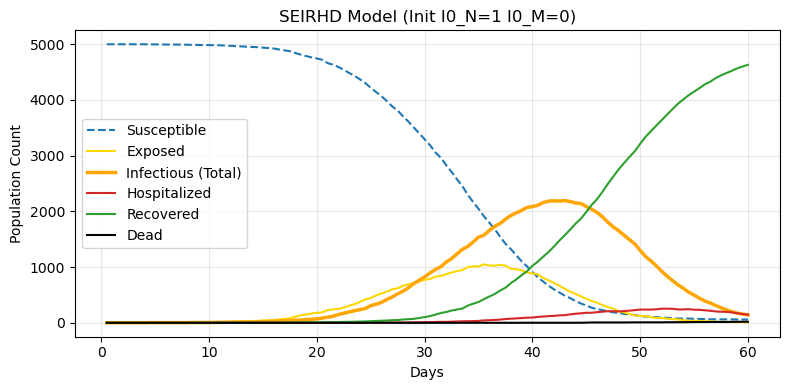

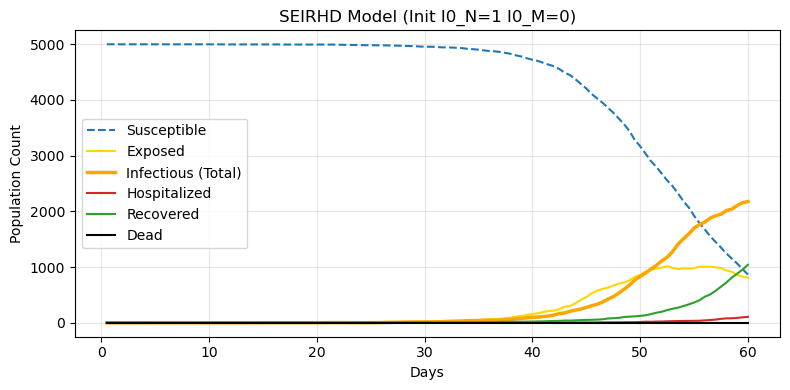

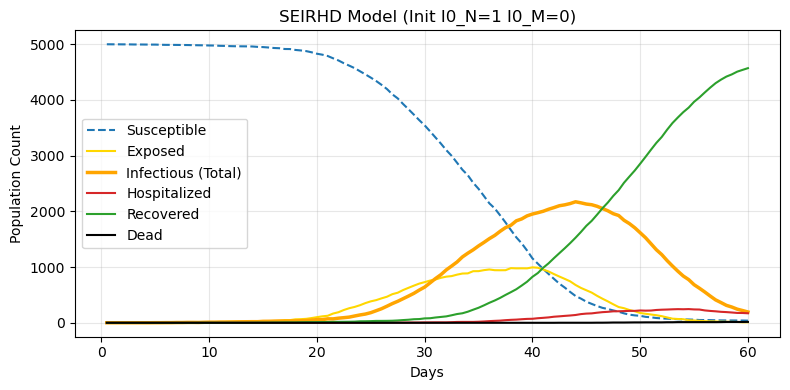

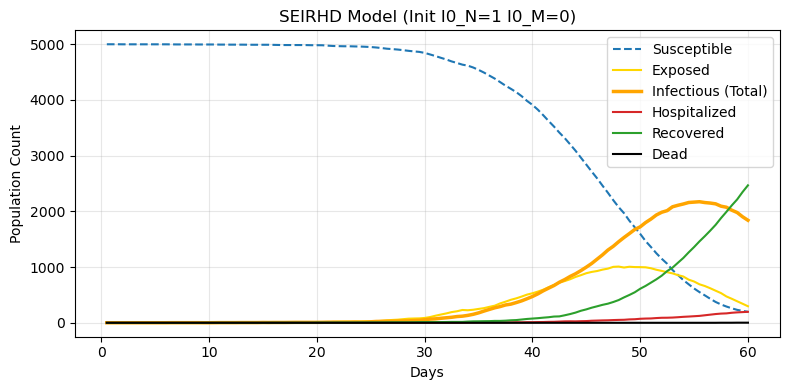

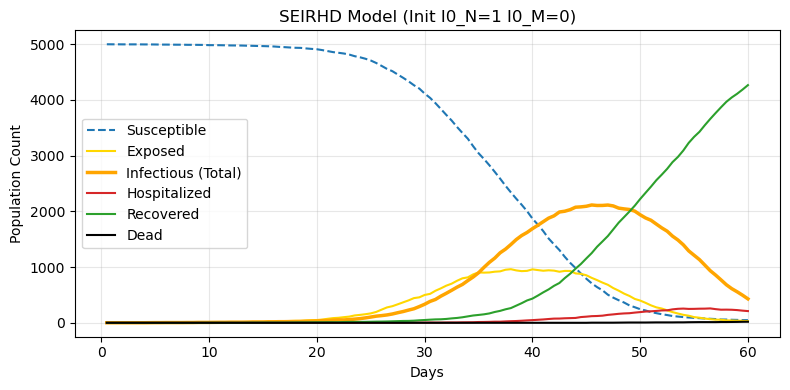

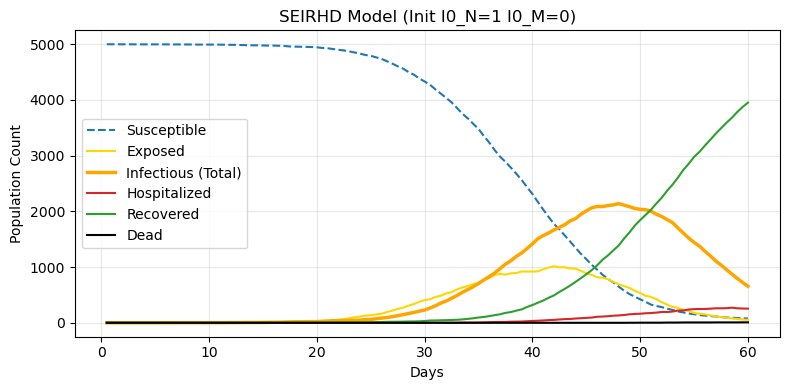

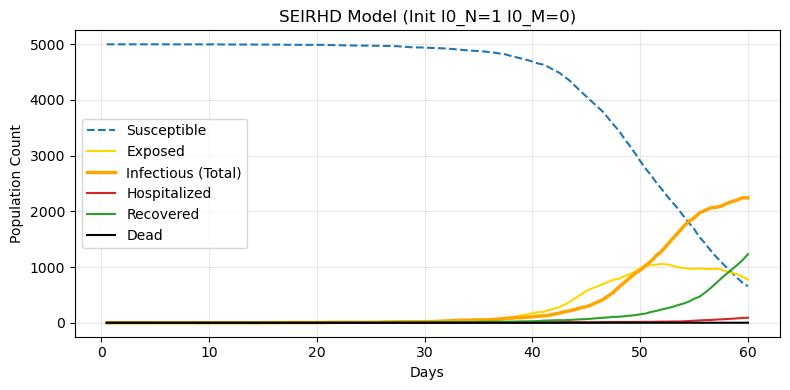

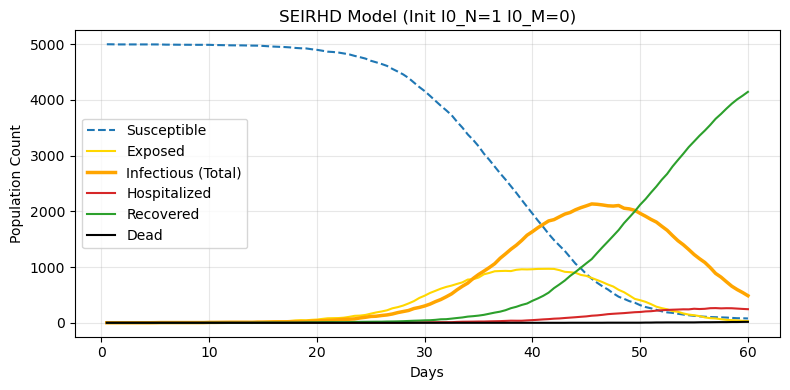

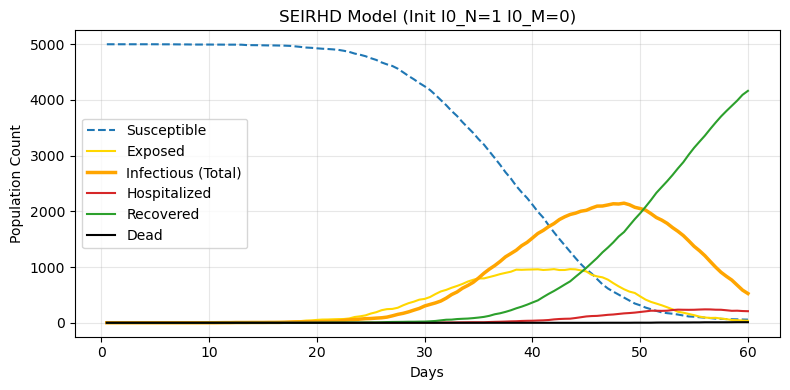

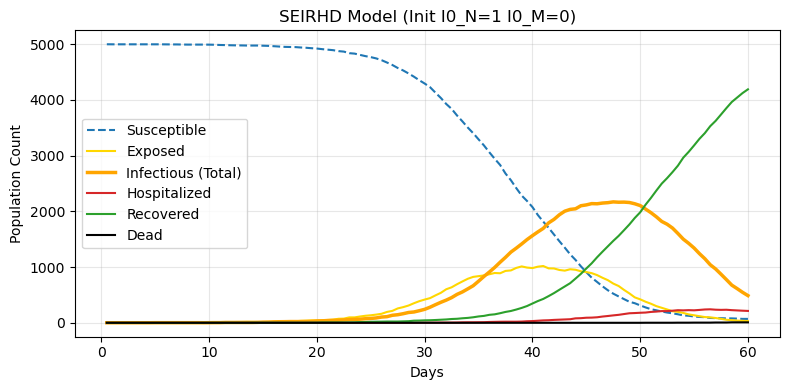

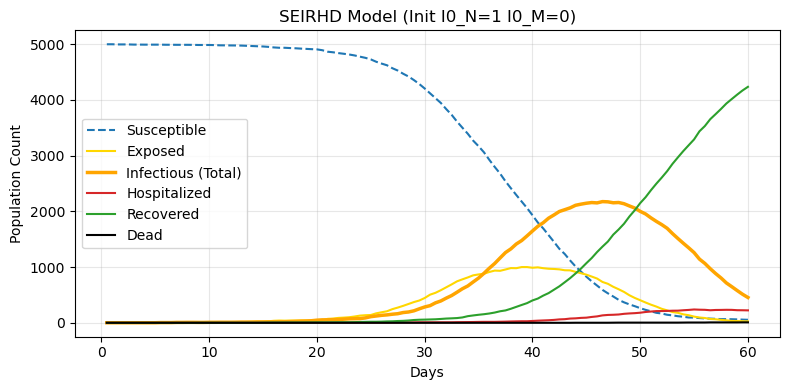

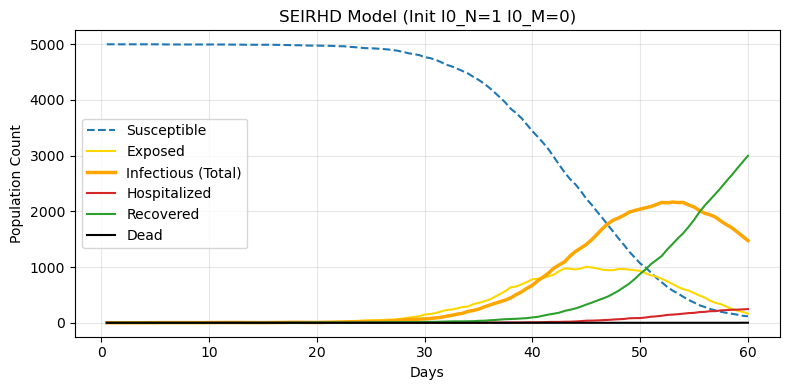

In [5]:
params = model.Params(
    T=DAYS * 24,
    N=N_AGENTS,
    alpha=3,
    initial_infected_normal=1,
    initial_infected_multispreader=0,
    exposed=0,
    ratios=model.AgentTypeRatio(retired=0.2, adult=0.6, child=0.2),
    schools=4,
    primary_care=20,
    hospitals=1,
    other_working_places=100,
    public_places=50
)

for i in range(20):
    sim = model.Simulation(params=params, seed=i)
    sim.init()
    sim.run(dt=12.0) 
    df = pd.DataFrame(sim.get_stats_df())
    df["days"] = df["time"] / 24
    plot_results(df, params.N)